In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras import Sequential, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.metrics import Precision, Recall
!pip install shap lime
import shap
import lime
import lime.lime_tabular
import seaborn as sns

In [91]:
Products = pd.read_csv('olist_products_dataset.csv')

Reviews = pd.read_csv('olist_order_reviews_dataset.csv')

Order_Items = pd.read_csv('olist_order_items_dataset.csv')

Customers = pd.read_csv('olist_customers_dataset.csv')

Orders = pd.read_csv('olist_orders_dataset.csv')


In [92]:
Products.head(10)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
5,41d3672d4792049fa1779bb35283ed13,instrumentos_musicais,60.0,745.0,1.0,200.0,38.0,5.0,11.0
6,732bd381ad09e530fe0a5f457d81becb,cool_stuff,56.0,1272.0,4.0,18350.0,70.0,24.0,44.0
7,2548af3e6e77a690cf3eb6368e9ab61e,moveis_decoracao,56.0,184.0,2.0,900.0,40.0,8.0,40.0
8,37cc742be07708b53a98702e77a21a02,eletrodomesticos,57.0,163.0,1.0,400.0,27.0,13.0,17.0
9,8c92109888e8cdf9d66dc7e463025574,brinquedos,36.0,1156.0,1.0,600.0,17.0,10.0,12.0


In [93]:
Products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [94]:
Products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [95]:
Products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [96]:
Products = Products.dropna(subset=[
    'product_name_lenght'
])

In [97]:
Products[Products.isnull().any(axis=1)]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
8578,09ff539a621711667c43eba6a3bd8466,bebes,60.0,865.0,3.0,NaN,NaN,NaN,NaN


In [98]:
#drop  the product with product_weight_g null
Products = Products.dropna(subset=['product_weight_g'])


In [99]:
Reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [100]:
Reviews = Reviews.drop(columns=['review_comment_title'])
Reviews = Reviews.drop(columns=['review_comment_message'])

In [101]:
Reviews.isnull().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [102]:
Reviews.head(10)

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,2018-05-22 00:00:00,2018-05-23 16:45:47


In [103]:
#convert timestamps to datetime datatype (review_creation_date	review_answer_timestamp)
Reviews['review_creation_date'] = pd.to_datetime(Reviews['review_creation_date'])
Reviews['review_answer_timestamp'] = pd.to_datetime(Reviews['review_answer_timestamp'])

In [104]:
Orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [105]:
Orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [106]:
Orders.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [107]:
Orders[Orders.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [108]:
shipped_orders = Orders[Orders['order_status'] == 'delivered'].copy()
shipped_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [109]:
Orders['order_status'].unique()


array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [110]:
# Filter orders with no delivery date
missing_delivery = Orders[Orders['order_delivered_customer_date'].isnull()]

# See what their statuses are
missing_delivery['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [111]:
Orders['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [112]:
#convert timestamps to datetime datatype (order_purchase_timestamp	order_approved_at	order_delivered_carrier_date	order_delivered_customer_date	order_estimated_delivery_date)
Orders['order_purchase_timestamp'] = pd.to_datetime(Orders['order_purchase_timestamp'])
Orders['order_approved_at'] = pd.to_datetime(Orders['order_approved_at'])
Orders['order_delivered_carrier_date'] = pd.to_datetime(Orders['order_delivered_carrier_date'])
Orders['order_delivered_customer_date'] = pd.to_datetime(Orders['order_delivered_customer_date'])
Orders['order_estimated_delivery_date'] = pd.to_datetime(Orders['order_estimated_delivery_date'])


In [113]:
# ✅ Calculate the delivery time difference (keeps NaNs if any date is missing)
Orders['delivery_delay'] = Orders['order_delivered_customer_date'] - Orders['order_estimated_delivery_date']

# ✅ Create a filtered DataFrame with only valid (non-null) differences
valid_diff = Orders[Orders['delivery_delay'].notna()]


In [114]:
# Filter canceled orders that somehow have a delivery date
canceled_with_delivery = Orders[
    (Orders['order_status'] == 'canceled') &
    (Orders['order_delivered_customer_date'].notnull())
]

# Show the relevant columns
canceled_with_delivery[['order_id', 'order_status', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head(10)

,order_id,order_status,order_delivered_customer_date,order_estimated_delivery_date
2921,1950d777989f6a877539f53795b4c3c3,canceled,2018-03-21 22:03:51,2018-03-09
8791,dabf2b0e35b423f94618bf965fcb7514,canceled,2016-10-16 14:36:59,2016-11-30
58266,770d331c84e5b214bd9dc70a10b829d0,canceled,2016-10-14 15:07:11,2016-11-29
59332,8beb59392e21af5eb9547ae1a9938d06,canceled,2016-10-19 18:47:43,2016-11-30
92636,65d1e226dfaeb8cdc42f665422522d14,canceled,2016-11-08 10:58:34,2016-11-25
94399,2c45c33d2f9cb8ff8b1c86cc28c11c30,canceled,2016-11-09 14:53:50,2016-12-08


In [115]:
canceled_with_delivery[['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']].head(10)

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date
2921,2018-02-19 19:48:52,2018-03-21 22:03:51,2018-03-09
8791,2016-10-09 00:56:52,2016-10-16 14:36:59,2016-11-30
58266,2016-10-07 14:52:30,2016-10-14 15:07:11,2016-11-29
59332,2016-10-08 20:17:50,2016-10-19 18:47:43,2016-11-30
92636,2016-10-03 21:01:41,2016-11-08 10:58:34,2016-11-25
94399,2016-10-09 15:39:56,2016-11-09 14:53:50,2016-12-08


In [116]:
not_delivered = Orders[Orders['order_delivered_customer_date'].isnull()]
not_delivered['order_status'].value_counts()

,count
order_status,
shipped,1107
canceled,619
unavailable,609
invoiced,314
processing,301
delivered,8
created,5
approved,2


In [117]:
Orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8 days +21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6 days +15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18 days +18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13 days +00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10 days +18:17:02


In [118]:
Order_Items.head(10)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.90,12.69
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.00,70.75
8,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65
9,0005f50442cb953dcd1d21e1fb923495,1,4535b0e1091c278dfd193e5a1d63b39f,ba143b05f0110f0dc71ad71b4466ce92,2018-07-06 14:10:56,53.99,11.40


In [119]:
#convert timestamps to datetime datatype (shipping_limit_date)
Order_Items['shipping_limit_date'] = pd.to_datetime(Order_Items['shipping_limit_date'])

In [120]:
Order_Items['shipping_limit_date'].dtypes

dtype('<M8[ns]')

In [121]:
Customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [122]:
Orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,-8 days +21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,-6 days +15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,-18 days +18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,-13 days +00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,-10 days +18:17:02
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,-6 days +10:57:55
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,NaT
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,-12 days +12:55:51
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,-32 days +14:08:10
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,-7 days +17:14:30


In [123]:
#check nulls in all datasets
Products.isnull().sum()


,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0


In [124]:
Reviews.isnull().sum()


,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [125]:
Orders.isnull().sum()


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0
delivery_delay,2965


In [126]:
# Drop rows where order_status is 'delivered' and order_delivered_customer_date is NaN
Orders = Orders[~((Orders['order_status'] == 'delivered') & (Orders['order_delivered_customer_date'].isnull()))]

In [127]:
# Check if any delivered orders still have null delivery date
Orders[(Orders['order_status'] == 'delivered') & (Orders['order_delivered_customer_date'].isnull())]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay


In [128]:
Order_Items.isnull().sum()


,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [129]:
Customers.isnull().sum()

,0
customer_id,0
customer_unique_id,0
customer_zip_code_prefix,0
customer_city,0
customer_state,0


In [130]:
# Start with Order_Items (most granular level)
mergeddf = Order_Items.merge(Products, on='product_id', how='inner')
mergeddf = mergeddf.merge(Orders, on='order_id', how='inner')
mergeddf = mergeddf.merge(Customers, on='customer_id', how='left')
mergeddf = mergeddf.merge(Reviews, on='order_id', how='inner')  # Fixed variable name

# Check for duplicates
print(f"Shape after merges: {mergeddf.shape}")
print(f"Original Order_Items shape: {Order_Items.shape}")

Shape after merges: (110765, 31)
Original Order_Items shape: (112650, 7)


In [228]:
mergeddf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110765 entries, 0 to 110764
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype          
---  ------                         --------------   -----          
 0   order_id                       110765 non-null  object         
 1   order_item_id                  110765 non-null  int64          
 2   product_id                     110765 non-null  object         
 3   seller_id                      110765 non-null  object         
 4   shipping_limit_date            110765 non-null  datetime64[ns] 
 5   price                          110765 non-null  float64        
 6   freight_value                  110765 non-null  float64        
 7   product_category_name          110765 non-null  object         
 8   product_name_lenght            110765 non-null  float64        
 9   product_description_lenght     110765 non-null  float64        
 10  product_photos_qty             110765 non-null  float64 

In [132]:
mergeddf.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0


   customer_state   product_category_name  avg_review_score  review_count
0              BA  informatica_acessorios          3.949612           258
1              CE            beleza_saude          3.854545           165
2              DF           esporte_lazer          4.132743           226
3              ES           esporte_lazer          4.179191           173
4              GO           esporte_lazer          4.144578           166
5              MG        malas_acessorios          4.426230           183
6              PE            beleza_saude          4.054852           237
7              PR              perfumaria          4.392157           153
8              RJ            beleza_saude          4.063208          1060
9              RS              perfumaria          4.350649           154
10             SC      relogios_presentes          4.157609           184
11             SP  livros_interesse_geral          4.484444           225

Number of states analyzed after filte

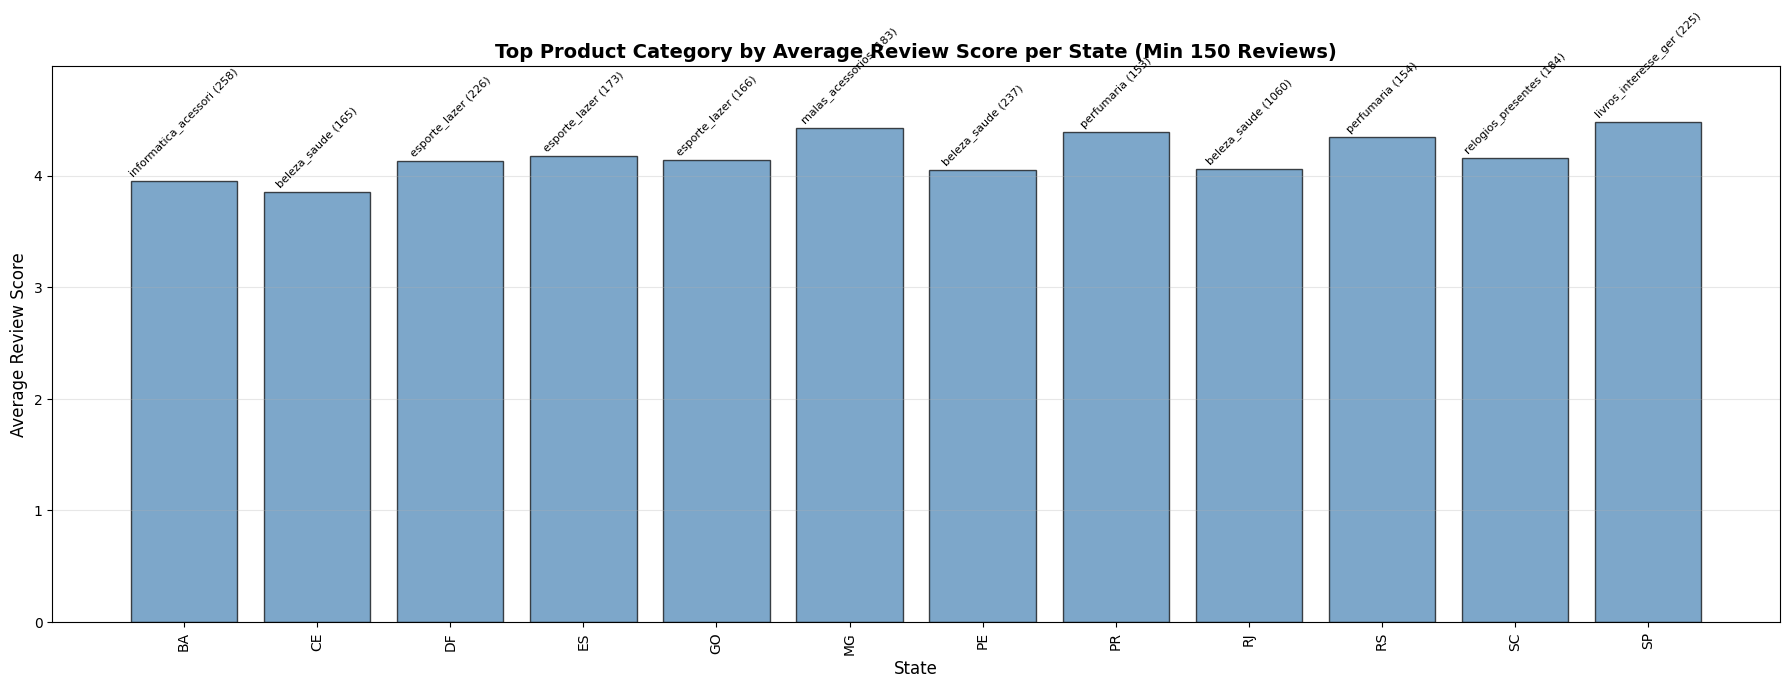

In [133]:
# --------------------------
# 1️⃣ Compute average review score and count per state and product category
# --------------------------
avg_scores = mergeddf.groupby(
    ['customer_state', 'product_category_name']
).agg(
    avg_review_score=('review_score', 'mean'),
    review_count=('review_score', 'count')
).reset_index()

# --------------------------
# 2️⃣ Filter for categories with a minimum number of reviews (e.g., 10 or more)
# --------------------------
min_reviews_threshold = 150  # You can adjust this threshold
filtered_scores = avg_scores[avg_scores['review_count'] >= min_reviews_threshold].copy()


# --------------------------
# 3️⃣ Find the top product category per state from the filtered data
# --------------------------
# Handle cases where a state might not have any categories meeting the threshold
top_categories = filtered_scores.loc[
    filtered_scores.groupby('customer_state')['avg_review_score'].idxmax()
].sort_values('customer_state').reset_index(drop=True)

# --------------------------
# 4️⃣ Display the results
# --------------------------
print(top_categories)
print(f"\nNumber of states analyzed after filtering: {len(top_categories)}")


# --------------------------
# 5️⃣ Improved Visualization (update to use filtered_scores and correct column name)
# --------------------------
plt.figure(figsize=(18, 7)) # Increased figure size for better readability
bars = plt.bar(
    range(len(top_categories)),
    top_categories['avg_review_score'], # Use avg_review_score
    color='steelblue',
    edgecolor='black',
    alpha=0.7
)

# Set x-axis labels to state names
plt.xticks(range(len(top_categories)), top_categories['customer_state'], rotation=90)

# Add category names on top of bars
for i, row in top_categories.iterrows():
    plt.text(
        i,
        row['avg_review_score'] + 0.02,  # Use avg_review_score
        f"{row['product_category_name'][:20]} ({row['review_count']})",  # Add review count
        ha='center',
        va='bottom',
        fontsize=8,
        rotation=45
    )

plt.title(f'Top Product Category by Average Review Score per State (Min {min_reviews_threshold} Reviews)', fontsize=14, fontweight='bold')
plt.ylabel('Average Review Score', fontsize=12)
plt.xlabel('State', fontsize=12)
plt.ylim(0, top_categories['avg_review_score'].max() + 0.5)  # Use avg_review_score
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [134]:
#● Which product category has the highest average review score in each region? Q1

# calculate the average number of reviews on each product category
avg_reviews_per_category = mergeddf.groupby('product_category_name')['review_score'].count()
print (avg_reviews_per_category)





product_category_name
agro_industria_e_comercio     212
alimentos                     495
alimentos_bebidas             279
artes                         207
artes_e_artesanato             24
                             ... 
sinalizacao_e_seguranca       197
tablets_impressao_imagem       81
telefonia                    4517
telefonia_fixa                262
utilidades_domesticas        6943
Name: review_score, Length: 73, dtype: int64


In [135]:
# Filter for delivered orders
delivered_orders = mergeddf[mergeddf['order_status'] == 'delivered']

# Calculate the average delivery delay for delivered orders (in days)
average_delivery_delay_delivered = delivered_orders['delivery_delay'].mean()

# Convert Timedelta to days (float)
average_delay_days = average_delivery_delay_delivered / pd.Timedelta(days=1)

print(f"Average delivery delay for delivered orders: {average_delay_days:.2f} days")

# Print number of review scores (count, not sum)
print(f"Number of review scores: {mergeddf['review_score'].count()}")


Average delivery delay for delivered orders: -11.38 days
Number of review scores: 110765


In [136]:
delayed_orders = mergeddf[mergeddf['delivery_delay'].dt.days > 0]

print(f"Number of delayed orders: {len(delayed_orders)}")
display(delayed_orders[['order_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay']].head(10))

Number of delayed orders: 6999


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
21,000e906b789b55f64edcb1f84030f90d,delivered,2017-11-21 18:54:23,2017-12-09 17:27:23,2017-12-07,2 days 17:27:23
36,0017afd5076e074a48f1f1a4c7bac9c5,delivered,2017-04-06 22:16:10,2017-05-23 08:32:07,2017-05-19,4 days 08:32:07
44,001c85b5f68d2be0cb0797afc9e8ce9a,delivered,2017-11-24 19:19:18,2017-12-22 18:37:40,2017-12-14,8 days 18:37:40
45,001d8f0e34a38c37f7dba2a37d4eba8b,delivered,2017-05-14 17:19:44,2017-05-26 13:14:50,2017-05-24,2 days 13:14:50
46,001d8f0e34a38c37f7dba2a37d4eba8b,delivered,2017-05-14 17:19:44,2017-05-26 13:14:50,2017-05-24,2 days 13:14:50
79,0030d783f979fbc5981e75613b057344,delivered,2017-11-24 20:03:02,2018-01-06 00:25:43,2017-12-15,22 days 00:25:43
82,00324b3eda39ba5ecce3945823e3594c,delivered,2018-04-10 01:14:18,2018-05-03 20:29:24,2018-04-30,3 days 20:29:24
83,0032d07457ae9c806c79368d7d9ce96b,delivered,2018-03-10 18:53:06,2018-04-29 21:08:59,2018-04-17,12 days 21:08:59
102,003a94f778ef8cfd50247c8c1b582257,delivered,2018-08-03 14:52:31,2018-08-24 00:18:38,2018-08-15,9 days 00:18:38
105,003d804eef0e1b856881cd18e0cc0d4c,delivered,2017-11-17 19:43:10,2018-01-10 23:19:43,2017-12-18,23 days 23:19:43


In [137]:
delayed_orders_from_orders = Orders[Orders['delivery_delay'].dt.days > 0]

print(f"Number of delayed orders from the Orders DataFrame: {len(delayed_orders_from_orders)}")
display(delayed_orders_from_orders[['order_id', 'order_status', 'order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay']].head(10))

Number of delayed orders from the Orders DataFrame: 6535


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_delay
20,203096f03d82e0dffbc41ebc2e2bcfb7,delivered,2017-09-18 14:31:30,2017-10-09 22:23:46,2017-09-28,11 days 22:23:46
25,fbf9ac61453ac646ce8ad9783d7d0af6,delivered,2018-02-20 23:46:53,2018-03-21 22:03:54,2018-03-12,9 days 22:03:54
41,6ea2f835b4556291ffdc53fa0b3b95e8,delivered,2017-11-24 21:27:48,2017-12-28 18:59:23,2017-12-21,7 days 18:59:23
57,66e4624ae69e7dc89bd50222b59f581f,delivered,2018-03-09 14:50:15,2018-04-03 13:28:46,2018-04-02,1 days 13:28:46
58,a685d016c8a26f71a0bb67821070e398,delivered,2017-03-13 18:14:36,2017-04-06 13:37:16,2017-03-30,7 days 13:37:16
97,6a0a8bfbbe700284feb0845d95e0867f,delivered,2017-11-22 11:32:22,2017-12-28 19:43:00,2017-12-11,17 days 19:43:00
102,a5474c0071dd5d1074e12d417078bbd0,delivered,2018-07-30 22:41:44,2018-08-03 19:28:47,2018-08-02,1 days 19:28:47
110,9d531c565e28c3e0d756192f84d8731f,delivered,2017-11-28 21:00:44,2018-01-23 21:38:52,2017-12-22,32 days 21:38:52
115,8fc207e94fa91a7649c5a5dab690272a,delivered,2017-11-26 17:49:46,2018-01-20 13:42:22,2017-12-19,32 days 13:42:22
143,33a3edb84b9df4cb49546859b990ac6d,delivered,2018-02-21 17:15:49,2018-03-22 00:03:53,2018-03-16,6 days 00:03:53


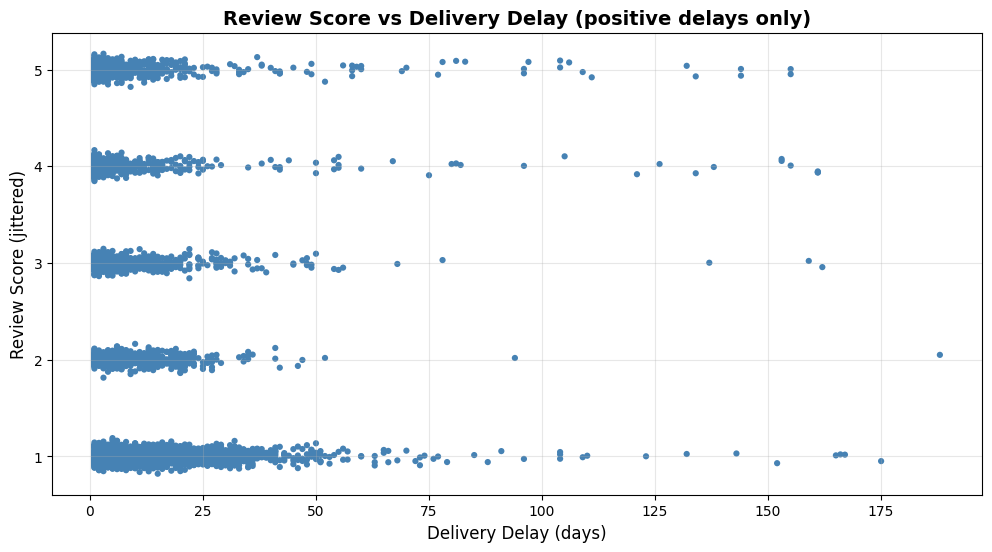

In [138]:
# Filter only positive delays
positive_delays = mergeddf[mergeddf['delivery_delay'].dt.days > 0].copy()

plt.figure(figsize=(12,6))

# Add small jitter to review scores to avoid stacking (since they're integers 1-5)
jittered_score = positive_delays['review_score'] + np.random.normal(0, 0.05, len(positive_delays))

plt.scatter(
    positive_delays['delivery_delay'].dt.days,
    jittered_score,
    s=20,          # small points
    alpha=1,     # transparency to reduce overplotting
    color='steelblue',
    edgecolor='none'
)

plt.xlabel("Delivery Delay (days)", fontsize=12)
plt.ylabel("Review Score (jittered)", fontsize=12)
plt.title("Review Score vs Delivery Delay (positive delays only)", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

States with Highest Proportion of Negative Reviews:
   customer_state  negative_count  total_reviews  negative_proportion  \
21             RR              13             50             0.260000   
1              AL             109            441             0.247166   
9              MA             188            812             0.231527   
18             RJ            3206          14250             0.224982   
24             SE              82            381             0.215223   
5              CE             304           1454             0.209078   
13             PA             219           1048             0.208969   
4              BA             741           3708             0.199838   
16             PI              99            531             0.186441   
2              AM              30            162             0.185185   

    negative_percentage  
21            26.000000  
1             24.716553  
9             23.152709  
18            22.498246  
24            

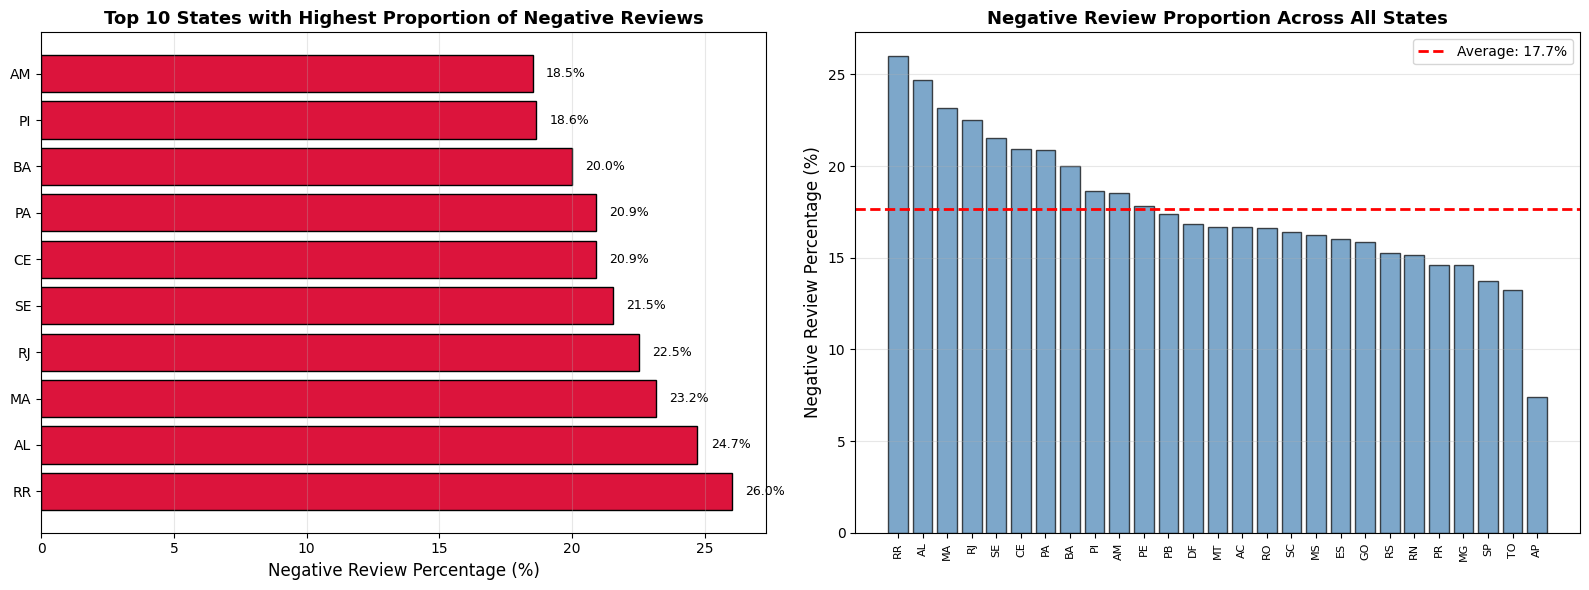


Overall negative review rate: 16.03%
State with highest negative reviews: RR (26.00%)
State with lowest negative reviews: AP (7.41%)


In [139]:
# --------------------------
# 1️⃣ Define negative reviews (typically scores 1-2 or 1-3)
# --------------------------
# Using 1-2 as negative (you can adjust to 1-3 if needed)
mergeddf['is_negative'] = mergeddf['review_score'] <= 2

# --------------------------
# 2️⃣ Calculate proportion of negative reviews per state
# --------------------------
negative_by_state = mergeddf.groupby('customer_state').agg({
    'is_negative': ['sum', 'count', 'mean']
}).reset_index()

negative_by_state.columns = ['customer_state', 'negative_count', 'total_reviews', 'negative_proportion']
negative_by_state['negative_percentage'] = negative_by_state['negative_proportion'] * 100

# Sort by proportion descending
negative_by_state = negative_by_state.sort_values('negative_proportion', ascending=False)

# --------------------------
# 3️⃣ Display results
# --------------------------
print("States with Highest Proportion of Negative Reviews:")
print(negative_by_state.head(10))

# --------------------------
# 4️⃣ Visualization
# --------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Top 10 states by negative review proportion
top_10_negative = negative_by_state.head(10)
ax1.barh(range(len(top_10_negative)), top_10_negative['negative_percentage'], color='crimson', edgecolor='black')
ax1.set_yticks(range(len(top_10_negative)))
ax1.set_yticklabels(top_10_negative['customer_state'])
ax1.set_xlabel('Negative Review Percentage (%)', fontsize=12)
ax1.set_title('Top 10 States with Highest Proportion of Negative Reviews', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add percentage labels on bars
for i, (idx, row) in enumerate(top_10_negative.iterrows()):
    ax1.text(row['negative_percentage'] + 0.5, i, f"{row['negative_percentage']:.1f}%",
             va='center', fontsize=9)

# Plot 2: All states map view
ax2.bar(range(len(negative_by_state)), negative_by_state['negative_percentage'],
        color='steelblue', edgecolor='black', alpha=0.7)
ax2.set_xticks(range(len(negative_by_state)))
ax2.set_xticklabels(negative_by_state['customer_state'], rotation=90, fontsize=8)
ax2.set_ylabel('Negative Review Percentage (%)', fontsize=12)
ax2.set_title('Negative Review Proportion Across All States', fontsize=13, fontweight='bold')
ax2.axhline(y=negative_by_state['negative_percentage'].mean(), color='red',
            linestyle='--', linewidth=2, label=f"Average: {negative_by_state['negative_percentage'].mean():.1f}%")
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------
# 5️⃣ Summary Statistics
# --------------------------
print(f"\nOverall negative review rate: {mergeddf['is_negative'].mean() * 100:.2f}%")
print(f"State with highest negative reviews: {negative_by_state.iloc[0]['customer_state']} ({negative_by_state.iloc[0]['negative_percentage']:.2f}%)")
print(f"State with lowest negative reviews: {negative_by_state.iloc[-1]['customer_state']} ({negative_by_state.iloc[-1]['negative_percentage']:.2f}%)")

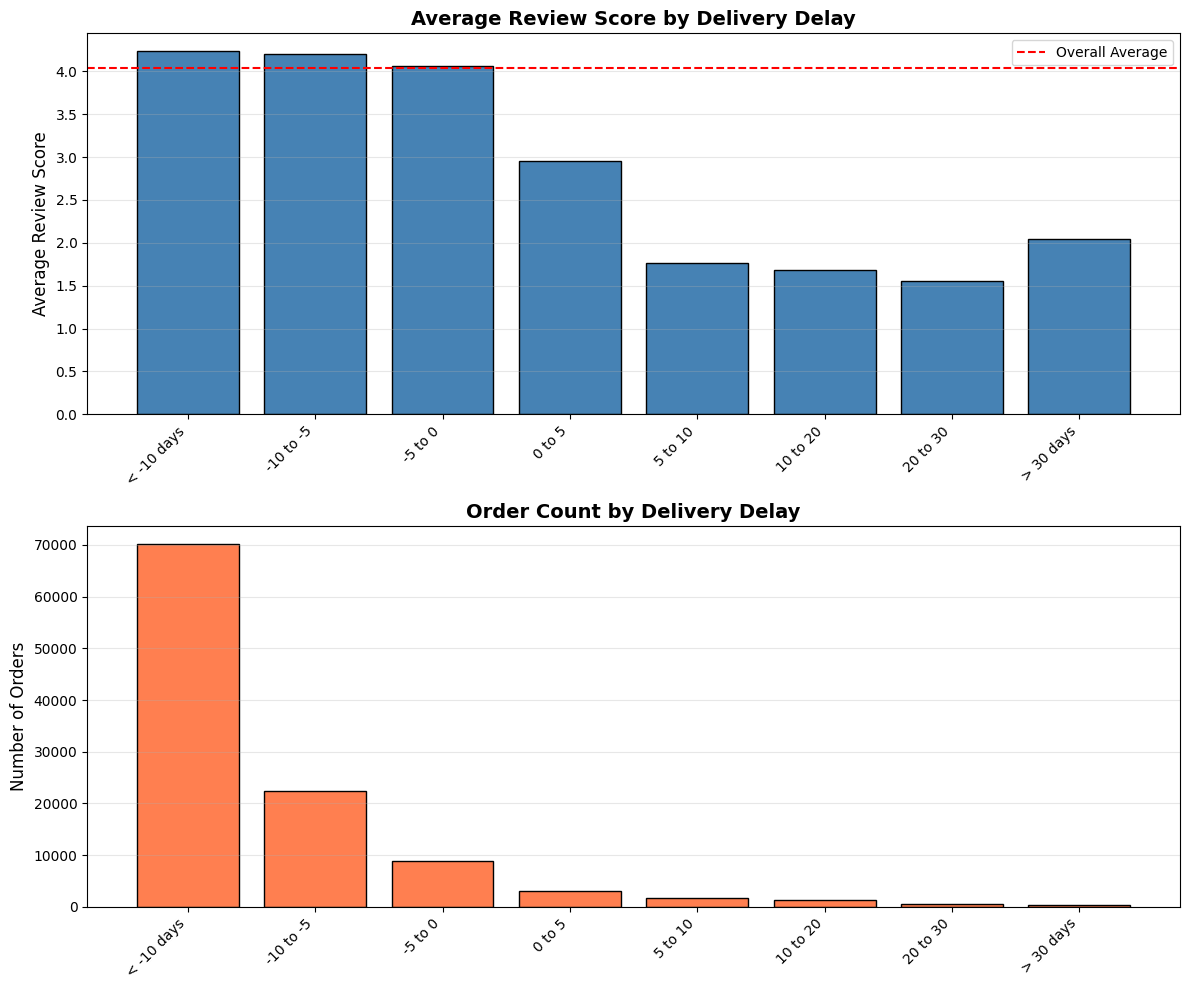

Summary of Delivery Delay vs Review Score:
    delay_bin  avg_review_score  count
0  < -10 days          4.230906  70180
1   -10 to -5          4.200418  22483
2     -5 to 0          4.056148   8816
3      0 to 5          2.949934   3016
4     5 to 10          1.769490   1783
5    10 to 20          1.678494   1381
6    20 to 30          1.551797    473
7   > 30 days          2.043353    346

Correlation between delivery_delay and review_score: 0.238


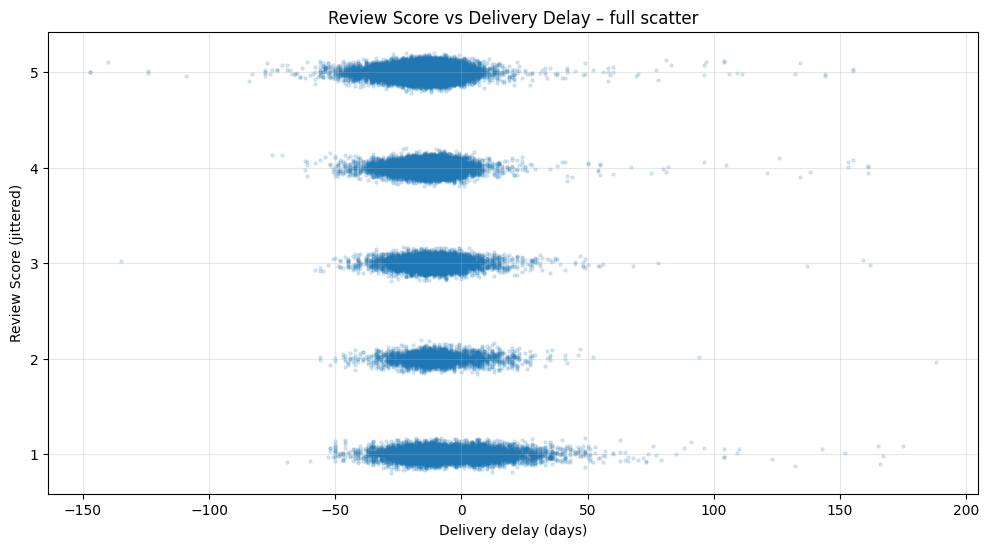

In [140]:
# Create delay bins
mergeddf['delay_bin'] = pd.cut(
    mergeddf['delivery_delay'].dt.days,
    bins=[-float('inf'), -10, -5, 0, 5, 10, 20, 30, float('inf')],
    labels=['< -10 days', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '20 to 30', '> 30 days']
)

# Calculate average review score per bin
delay_review = mergeddf.groupby('delay_bin', observed=True).agg({
    'review_score': ['mean', 'count']
}).reset_index()
delay_review.columns = ['delay_bin', 'avg_review_score', 'count']

# Visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Average review score by delay bin
ax1.bar(range(len(delay_review)), delay_review['avg_review_score'], color='steelblue', edgecolor='black')
ax1.set_xticks(range(len(delay_review)))
ax1.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax1.set_ylabel('Average Review Score', fontsize=12)
ax1.set_title('Average Review Score by Delivery Delay', fontsize=14, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=mergeddf['review_score'].mean(), color='red', linestyle='--', label='Overall Average')
ax1.legend()

# Plot 2: Count of orders per bin
ax2.bar(range(len(delay_review)), delay_review['count'], color='coral', edgecolor='black')
ax2.set_xticks(range(len(delay_review)))
ax2.set_xticklabels(delay_review['delay_bin'], rotation=45, ha='right')
ax2.set_ylabel('Number of Orders', fontsize=12)
ax2.set_title('Order Count by Delivery Delay', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary of Delivery Delay vs Review Score:")
print(delay_review)
print(f"\nCorrelation between delivery_delay and review_score: {mergeddf[['delivery_delay', 'review_score']].corr().iloc[0,1]:.3f}")


# Scatter: delivery delay vs review_score

plt.figure(figsize=(12,6))

# jitter review score so points don't stack on 1–5 only
jittered_score = mergeddf['review_score'] + np.random.normal(0, 0.05, len(mergeddf))

plt.scatter(
    mergeddf['delivery_delay'].dt.days,
    jittered_score,
    s=5,
    alpha=0.15     # key: transparency
)

plt.xlabel("Delivery delay (days)")
plt.ylabel("Review Score (jittered)")
plt.title("Review Score vs Delivery Delay – full scatter")
plt.grid(alpha=0.3)
plt.show()



# Task
Create a new column `sentiment_group` in the `mergeddf` DataFrame, categorizing `review_score` values: 1-2 as 'Negative', 3 as 'Neutral', and 4-5 as 'Positive'.

## Define Sentiment Groups

### Subtask:
Create a new target column `sentiment_group` in `mergeddf` based on `review_score`. Map review scores 1-2 to 'Negative', 3 to 'Neutral', and 4-5 to 'Positive'.


**Reasoning**:
I will create a new column 'sentiment_group' in the 'mergeddf' DataFrame based on the 'review_score' column. This will be achieved by defining conditions and choices for sentiment categories and then using `numpy.select` to apply this mapping, and then display the value counts to verify the new column.



In [141]:
conditions = [
    mergeddf['review_score'] <= 2,
    mergeddf['review_score'] == 3,
    mergeddf['review_score'] >= 4
]

choices = ['Negative', 'Neutral', 'Positive']

mergeddf['sentiment_group'] = np.select(conditions, choices, default='Unknown')

print(mergeddf['sentiment_group'].value_counts())
print(mergeddf[['review_score', 'sentiment_group']].head())

sentiment_group
Positive    83688
Negative    17755
Neutral      9322
Name: count, dtype: int64
   review_score sentiment_group
0             5        Positive
1             4        Positive
2             5        Positive
3             4        Positive
4             5        Positive


## Feature Engineering and Selection

### Subtask:
Select the specified features: `product_description_lenght`, `product_photos_qty`, `product_category_name`, `customer_state`, `delivery_delay`, `order_status`, `price`, and `freight_value`. Convert `delivery_delay` (a Timedelta object) into a numerical feature representing days.


**Reasoning**:
To begin the feature engineering and selection process, I will create a new DataFrame `features_df` by selecting the specified columns from `mergeddf`. Then, I will convert the `delivery_delay` column from a Timedelta object to a numerical representation in days, storing it in a new column named `delivery_delay_days`, and finally remove the original `delivery_delay` column, all in one step.



In [142]:
selected_features = [
    'product_description_lenght',
    'product_photos_qty',
    'product_category_name',
    'customer_state',
    'delivery_delay',
    'order_status',
    'price',
    'freight_value'
]

features_df = mergeddf[selected_features].copy()

# Convert 'delivery_delay' (Timedelta) to 'delivery_delay_days' (numerical days)
features_df['delivery_delay_days'] = features_df['delivery_delay'].dt.days

# Drop the original 'delivery_delay' column
features_df = features_df.drop(columns=['delivery_delay'])

print(features_df.head())
print(features_df.info())


   product_description_lenght  product_photos_qty product_category_name  \
0                       598.0                 4.0            cool_stuff   
1                       239.0                 2.0              pet_shop   
2                       695.0                 2.0      moveis_decoracao   
3                       480.0                 1.0            perfumaria   
4                       409.0                 1.0    ferramentas_jardim   

  customer_state order_status   price  freight_value  delivery_delay_days  
0             RJ    delivered   58.90          13.29                 -9.0  
1             SP    delivered  239.90          19.93                 -3.0  
2             MG    delivered  199.00          17.87                -14.0  
3             SP    delivered   12.99          12.79                 -6.0  
4             SP    delivered  199.90          18.14                -16.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110765 entries, 0 to 110764
Data columns (t

## Handle Missing Values and Encode Categorical Features

### Subtask:
Address any remaining missing values in the selected features. Apply one-hot encoding to categorical features (`product_category_name`, `customer_state`, `order_status`) and scale numerical features (`product_description_lenght`, `product_photos_qty`, `delivery_delay_days`, `price`, `freight_value`) using `StandardScaler`.


**Reasoning**:
The first step is to handle the missing values in the `delivery_delay_days` column by imputing them with the median, as identified in the subtask instructions. This ensures that the numerical scaling and subsequent model training are not affected by missing data.



In [143]:
median_delivery_delay = features_df['delivery_delay_days'].median()
features_df['delivery_delay_days'].fillna(median_delivery_delay, inplace=True)

print("Missing values after imputation:")
print(features_df.isnull().sum())

Missing values after imputation:
product_description_lenght    0
product_photos_qty            0
product_category_name         0
customer_state                0
order_status                  0
price                         0
freight_value                 0
delivery_delay_days           0
dtype: int64


/tmp/ipython-input-3332846310.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  features_df['delivery_delay_days'].fillna(median_delivery_delay, inplace=True)


**Reasoning**:
Now that missing values have been handled, the next step is to apply one-hot encoding to the identified categorical features and scale the numerical features as per the instructions. This prepares the data for machine learning models.



In [144]:
median_delivery_delay = features_df['delivery_delay_days'].median()
features_df['delivery_delay_days'] = features_df['delivery_delay_days'].fillna(median_delivery_delay)

# Identify categorical and numerical columns for encoding and scaling
categorical_cols = ['product_category_name', 'customer_state', 'order_status']
numerical_cols = [
    'product_description_lenght',
    'product_photos_qty',
    'delivery_delay_days',
    'price',
    'freight_value'
]

# Apply one-hot encoding to categorical features
features_encoded = pd.get_dummies(features_df[categorical_cols], drop_first=True)

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to numerical features
features_scaled = scaler.fit_transform(features_df[numerical_cols])
features_scaled = pd.DataFrame(features_scaled, columns=numerical_cols, index=features_df.index)

# Combine scaled numerical features and one-hot encoded categorical features into DataFrame X
X = pd.concat([features_scaled, features_encoded], axis=1)

print("Shape of X after encoding and scaling:", X.shape)
print(X.head())


Shape of X after encoding and scaling: (110765, 109)
   product_description_lenght  product_photos_qty  delivery_delay_days  \
0                   -0.289705            1.042499             0.310410   
1                   -0.840640           -0.120435             0.911473   
2                   -0.140845           -0.120435            -0.190476   
3                   -0.470792           -0.701903             0.610941   
4                   -0.579752           -0.701903            -0.390831   

      price  freight_value  product_category_name_alimentos  \
0 -0.338665      -0.425075                            False   
1  0.656755      -0.005210                            False   
2  0.431823      -0.135469                            False   
3 -0.591149      -0.456691                            False   
4  0.436772      -0.118396                            False   

   product_category_name_alimentos_bebidas  product_category_name_artes  \
0                                    False      

## Split Data into Training and Test Sets

### Subtask:
Split the preprocessed features and the `sentiment_group` target variable into training and testing sets to prepare for model training and evaluation.


**Reasoning**:
To prepare the target variable for model training, I will first extract the 'sentiment_group' column from `mergeddf` and then one-hot encode it to convert the categorical labels into a numerical format suitable for machine learning algorithms. The order of categories will be specified to ensure consistent encoding.



In [145]:
conditions = [
    mergeddf['review_score'] <= 2,
    mergeddf['review_score'] == 3,
    mergeddf['review_score'] >= 4
]

choices = ['Negative', 'Neutral', 'Positive']

mergeddf['sentiment_group'] = np.select(conditions, choices, default='Unknown')

print(mergeddf['sentiment_group'].value_counts())
print(mergeddf[['review_score', 'sentiment_group']].head())

sentiment_group
Positive    83688
Negative    17755
Neutral      9322
Name: count, dtype: int64
   review_score sentiment_group
0             5        Positive
1             4        Positive
2             5        Positive
3             4        Positive
4             5        Positive


In [146]:
# create target y and one-hot encode it
y = mergeddf['sentiment_group']          # this is the label column you created earlier
y_encoded = pd.get_dummies(y)            # one-hot encoding, gives 3 columns


**Reasoning**:
Now that the features and target variable are prepared, I will split them into training and testing sets using `train_test_split` to facilitate model training and evaluation. Stratification by the original `sentiment_group` is crucial to maintain the class distribution in both sets.



In [147]:
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nDistribution of sentiment_group in original data:")
print(y.value_counts(normalize=True))
print("\nDistribution of sentiment_group in y_train:")
print(y_train.sum(axis=0) / len(y_train))
print("\nDistribution of sentiment_group in y_test:")
print(y_test.sum(axis=0) / len(y_test))

Shape of X_train: (88612, 109)
Shape of X_test: (22153, 109)
Shape of y_train: (88612, 3)
Shape of y_test: (22153, 3)

Distribution of sentiment_group in original data:
sentiment_group
Positive    0.755546
Negative    0.160294
Neutral     0.084160
Name: proportion, dtype: float64

Distribution of sentiment_group in y_train:
Negative    0.160294
Neutral     0.084165
Positive    0.755541
dtype: float64

Distribution of sentiment_group in y_test:
Negative    0.160294
Neutral     0.084142
Positive    0.755564
dtype: float64


## Build and Compile Shallow FFNN Model

### Subtask:
Define a shallow Feedforward Neural Network using Keras/TensorFlow, configuring the input layer to match the number of features and the output layer with `softmax` activation for multi-class classification of the sentiment groups.


**Reasoning**:
I will define the input shape and number of classes from the training data, then construct a sequential Keras model with an input layer, a hidden dense layer with ReLU activation, and an output dense layer with softmax activation for multi-class classification. Finally, I will compile the model using the Adam optimizer and categorical crossentropy loss, including accuracy, precision, and recall metrics.



In [148]:
input_shape = X_train.shape[1]
num_classes = y_train.shape[1]

model = Sequential([
    Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(), Recall()]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │        14,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,467 (56.51 KB)

 Trainable params: 14,467 (56.51 KB)

 Non-trainable params: 0 (0.00 B)

In [149]:
# input_shape = X_train.shape[1]
# num_classes = y_train.shape[1]

# model = Sequential([
#     Input(shape=(input_shape,)),
#     layers.Dense(24, activation='tanh'),
#     layers.Dense(12, activation='tanh'),
#     layers.Dense(num_classes, activation='softmax')
# ])

# model.compile(
#     optimizer='adam',
#     loss='categorical_crossentropy',
#     metrics=['accuracy', Precision(), Recall()]
# )

# model.summary()

## Train FFNN Model

### Subtask:
Train the compiled FFNN model using the training data, monitoring its performance during the training process.


**Reasoning**:
To train the FFNN model, I will use the `model.fit()` method with the specified training and validation data, along with appropriate epochs and batch size, and store the training history.



In [150]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.7636 - loss: 0.6896 - precision_1: 0.7832 - recall_1: 0.7246 - val_accuracy: 0.7896 - val_loss: 0.6472 - val_precision_1: 0.7953 - val_recall_1: 0.7822
Epoch 2/20
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7917 - loss: 0.6403 - precision_1: 0.7972 - recall_1: 0.7835 - val_accuracy: 0.7925 - val_loss: 0.6442 - val_precision_1: 0.7971 - val_recall_1: 0.7846
Epoch 3/20
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7928 - loss: 0.6374 - precision_1: 0.7975 - recall_1: 0.7841 - val_accuracy: 0.7918 - val_loss: 0.6384 - val_precision_1: 0.7961 - val_recall_1: 0.7832
Epoch 4/20
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7933 - loss: 0.6310 - precision_1: 0.7984 - recall_1: 0.7858 - val_accuracy: 0.7934 - val_loss: 0.6357 - val_precision_1: 0.7980 - val_recall_1: 0.7864
Epoch 5/20
1385/1385 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7951 - loss: 0.6256 - precision_1: 0.7994 - recall

# Task
Predict sentiment groups on the test set using the trained FFNN model, and evaluate the model's performance using accuracy, precision, recall, and F1-score for each class and overall. Additionally, visualize the confusion matrix to understand prediction patterns, and summarize the model's effectiveness in predicting sentiment groups.

## Evaluate FFNN Model

### Subtask:
Predict sentiment groups on the test set and evaluate the model's performance using accuracy, precision, recall, and F1-score for each class and overall. Additionally, visualize the confusion matrix to understand prediction patterns.


**Reasoning**:
To evaluate the trained model, I will first use the model to make predictions on the test dataset. These predictions will be in the form of probability distributions, which then need to be converted into discrete class labels for evaluation against the true labels. This step generates both the raw predictions and their converted class labels.



In [151]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Use the model.predict() method to generate predictions (y_pred_probs) on the X_test data.
y_pred_probs = model.predict(X_test)

# 2. Convert the one-hot encoded y_pred_probs and y_test to single class labels using np.argmax()
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test.values, axis=1)


print("Predictions generated and converted to class labels.")

693/693 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predictions generated and converted to class labels.


In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score

# Get target names from y_test columns
target_names = y_test.columns.tolist()

# 1. Get the original 'order_status' for the X_test indices
# X_test preserves the original index from the mergeddf
original_order_status = mergeddf.loc[X_test.index, 'order_status']

# 2. Convert y_true and y_pred (numerical indices) back to sentiment group names
# 'target_names' was defined in cell e391bb51 as y_test.columns.tolist()
sentiment_map = {i: name for i, name in enumerate(target_names)}
y_true_sentiment_names = [sentiment_map[idx] for idx in y_true]
y_pred_sentiment_names = [sentiment_map[idx] for idx in y_pred]

# 3. Create a temporary DataFrame for analysis
analysis_df = pd.DataFrame({
    'order_status': original_order_status,
    'true_sentiment': y_true_sentiment_names,
    'predicted_sentiment': y_pred_sentiment_names
})

# 4. Calculate accuracy for each 'order_status'
analysis_df['is_correct'] = (analysis_df['true_sentiment'] == analysis_df['predicted_sentiment'])
accuracy_by_status = analysis_df.groupby('order_status')['is_correct'].mean().reset_index()
accuracy_by_status.rename(columns={'is_correct': 'accuracy'}, inplace=True)

# Sort by accuracy for better visualization
accuracy_by_status = accuracy_by_status.sort_values('accuracy', ascending=False)

print("Accuracy by Order Status:")
print(accuracy_by_status)

#print count of each order status
print("\nCount of each order status:")
print(analysis_df['order_status'].value_counts())

Accuracy by Order Status:
  order_status  accuracy
0     approved  1.000000
6  unavailable  1.000000
4   processing  0.903614
3     invoiced  0.833333
2    delivered  0.794660
1     canceled  0.784091
5      shipped  0.662281

Count of each order status:
order_status
delivered      21686
shipped          228
canceled          88
processing        83
invoiced          66
approved           1
unavailable        1
Name: count, dtype: int64


/tmp/ipython-input-2599962148.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='order_status', y='accuracy', data=accuracy_by_status, palette='viridis')


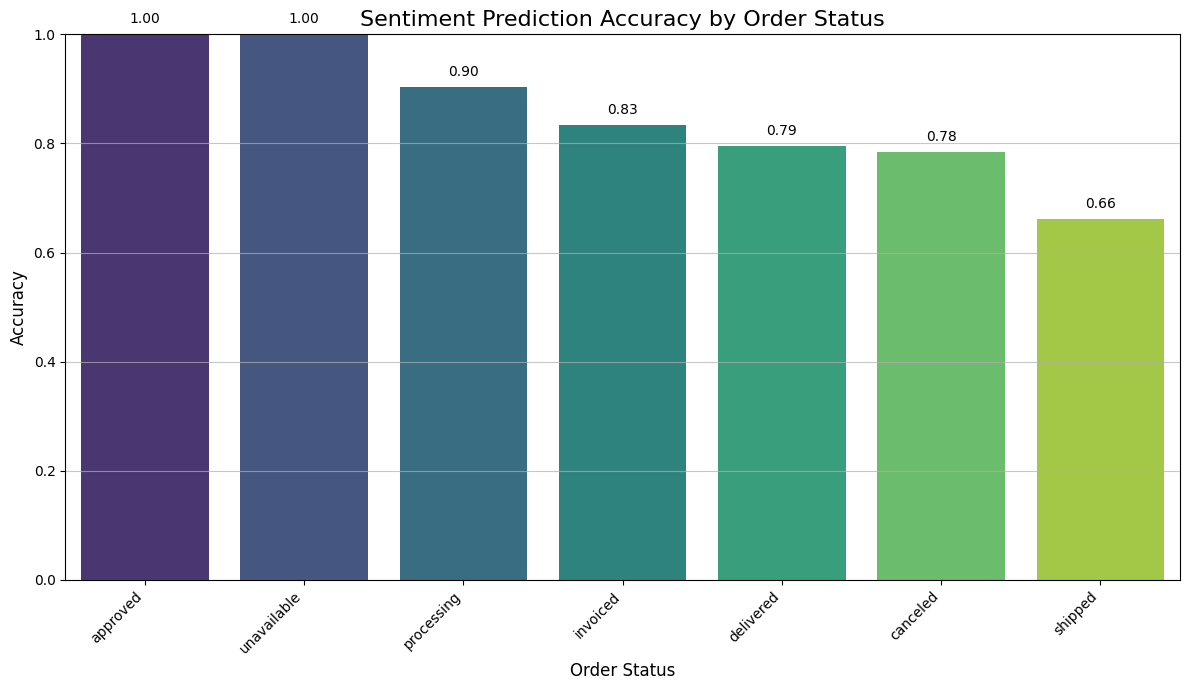

In [153]:
plt.figure(figsize=(12, 7))
sns.barplot(x='order_status', y='accuracy', data=accuracy_by_status, palette='viridis')
plt.title('Sentiment Prediction Accuracy by Order Status', fontsize=16)
plt.xlabel('Order Status', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.xticks(rotation=45, ha='right') # Rotate labels to prevent overlap

# Add accuracy values on top of bars using an enumerated index for correct placement
for i, row in enumerate(accuracy_by_status.itertuples()):
    plt.text(i, row.accuracy + 0.02, f'{row.accuracy:.2f}', color='black', ha="center")

plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

**Reasoning**:
Now that the predictions and true labels are in single class format, I will generate a classification report to assess metrics like accuracy, precision, recall, and F1-score for each sentiment group. Additionally, I will compute and visualize the confusion matrix to understand the model's performance in terms of true positives, true negatives, false positives, and false negatives for each class.



Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.31      0.44      3551
     Neutral       0.38      0.00      0.01      1864
    Positive       0.80      0.98      0.88     16738

    accuracy                           0.79     22153
   macro avg       0.64      0.43      0.44     22153
weighted avg       0.75      0.79      0.74     22153



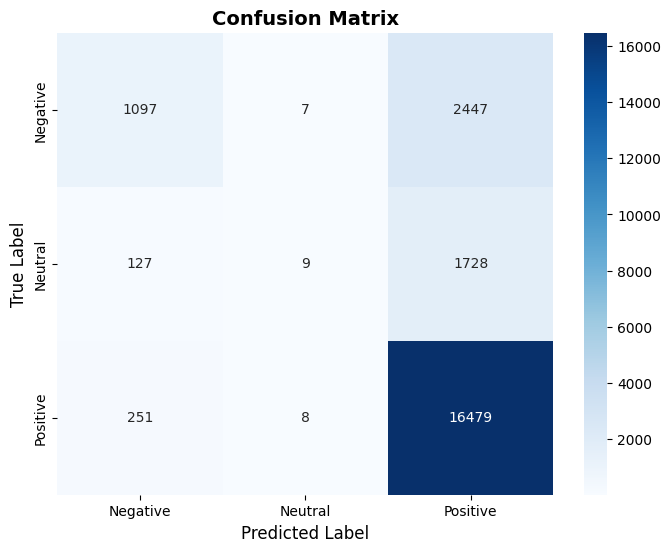

In [154]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get target names from y_test columns
target_names = y_test.columns.tolist()

# 3. Print a classification report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

# 4. Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 5. Create a heatmap of the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


In [155]:
# Evaluate on training set
train_loss, train_accuracy, train_precision, train_recall = model.evaluate(X_train, y_train, verbose=0)
print("\n--- Model Training Results ---")
print(f"Train Loss: {train_loss:.4f}")
print(f"Train Accuracy: {train_accuracy:.4f}")
print(f"Train Precision: {train_precision:.4f}")
print(f"Train Recall: {train_recall:.4f}")

# Evaluate on test set
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(X_test, y_test, verbose=0)
print("\n--- Model Test Results ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")


--- Model Training Results ---
Train Loss: 0.5964
Train Accuracy: 0.7990
Train Precision: 0.8042
Train Recall: 0.7921

--- Model Test Results ---
Test Loss: 0.6383
Test Accuracy: 0.7938
Test Precision: 0.7988
Test Recall: 0.7863


# Task
Prepare the necessary data for the SHAP Explainer. This involves sampling 1000 instances from `X_train` to create `X_train_sampled_shap` (background dataset) and 100 instances from `X_test` to create `X_test_subset_shap` for SHAP explanations (both global and local). Ensure `random_state=42` for reproducibility and that all data is converted to the correct numerical type (float) for SHAP compatibility.

## Prepare Data for SHAP Explainer

### Subtask:
Prepare the necessary data for the SHAP Explainer. This involves sampling 1000 instances from `X_train` to create `X_train_sampled_shap` (background dataset) and 100 instances from `X_test` to create `X_test_subset_shap` for SHAP explanations (both global and local). Ensure `random_state=42` for reproducibility and that all data is converted to the correct numerical type (float) for SHAP compatibility.


**Reasoning**:
To prepare the data for the SHAP explainer, I will first sample 1000 instances from the `X_train` DataFrame to create `X_train_sampled_shap` and 100 instances from `X_test` to create `X_test_subset_shap`, ensuring reproducibility with `random_state=42` and then convert both to NumPy arrays with a float data type as required for SHAP compatibility.



In [157]:
X_train_sampled_shap = X_train.sample(n=1000, random_state=42).to_numpy().astype(float)
X_test_subset_shap = X_test.sample(n=100, random_state=42).to_numpy().astype(float)

print(f"Shape of X_train_sampled_shap: {X_train_sampled_shap.shape}")
print(f"Dtype of X_train_sampled_shap: {X_train_sampled_shap.dtype}")
print(f"Shape of X_test_subset_shap: {X_test_subset_shap.shape}")
print(f"Dtype of X_test_subset_shap: {X_test_subset_shap.dtype}")

Shape of X_train_sampled_shap: (1000, 109)
Dtype of X_train_sampled_shap: float64
Shape of X_test_subset_shap: (100, 109)
Dtype of X_test_subset_shap: float64


## Initialize SHAP Explainer and Calculate SHAP Values

### Subtask:
Initialize the `shap.Explainer` with the trained FFNN `model` and the `X_train_sampled_shap` background dataset. Then, calculate the SHAP values for the selected subset of the test data (`X_test_subset_shap`) to understand feature contributions to predictions for all sentiment classes.


**Reasoning**:
To understand the feature contributions of the trained FFNN model, I will initialize a `shap.DeepExplainer` with the Keras model and the sampled training data as the background dataset. Then, I will compute the SHAP values for the sampled test data using this explainer.



In [158]:
# explainer = shap.DeepExplainer(model, X_train_sampled_shap)
# shap_values = explainer.shap_values(X_test_subset_shap)

# print(f"Type of shap_values: {type(shap_values)}")
# print(f"Number of outputs (classes): {len(shap_values)}")
# print(f"Shape of SHAP values for first class: {shap_values[0].shape}")

**Reasoning**:
The previous step successfully computed the SHAP values, but produced `UserWarning` messages from Keras regarding input structure. While these warnings often don't prevent the successful computation of SHAP values, the output message 'Number of outputs (classes): 100' was misleading as it incorrectly reported the number of samples instead of the number of classes. I will regenerate the same code while clarifying the print statements to accurately reflect the shape and dimensions of the SHAP values, ensuring correct interpretation for subsequent analysis.



In [159]:
# explainer = shap.DeepExplainer(model, X_train_sampled_shap)
# shap_values = explainer.shap_values(X_test_subset_shap)

# print(f"Type of shap_values: {type(shap_values)}")
# print(f"Overall SHAP values shape (samples, features, classes): {shap_values.shape}")
# print(f"SHAP values for first sample (features, classes): {shap_values[0].shape}")
# print(f"Number of target classes: {shap_values.shape[-1]}")

['product_description_lenght', 'product_photos_qty', 'delivery_delay_days', 'price', 'freight_value', 'product_category_name_alimentos', 'product_category_name_alimentos_bebidas', 'product_category_name_artes', 'product_category_name_artes_e_artesanato', 'product_category_name_artigos_de_festas', 'product_category_name_artigos_de_natal', 'product_category_name_audio', 'product_category_name_automotivo', 'product_category_name_bebes', 'product_category_name_bebidas', 'product_category_name_beleza_saude', 'product_category_name_brinquedos', 'product_category_name_cama_mesa_banho', 'product_category_name_casa_conforto', 'product_category_name_casa_conforto_2', 'product_category_name_casa_construcao', 'product_category_name_cds_dvds_musicais', 'product_category_name_cine_foto', 'product_category_name_climatizacao', 'product_category_name_consoles_games', 'product_category_name_construcao_ferramentas_construcao', 'product_category_name_construcao_ferramentas_ferramentas', 'product_category_

/tmp/ipython-input-1329549437.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, show=False)


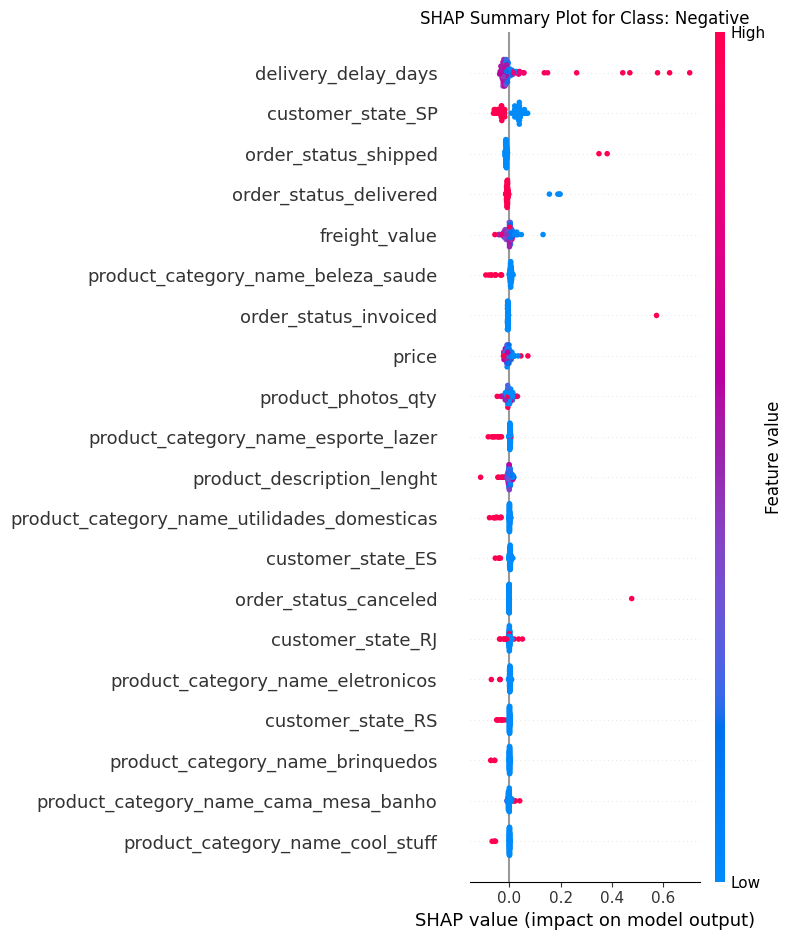


Summary plot for class: Neutral


/tmp/ipython-input-1329549437.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, show=False)


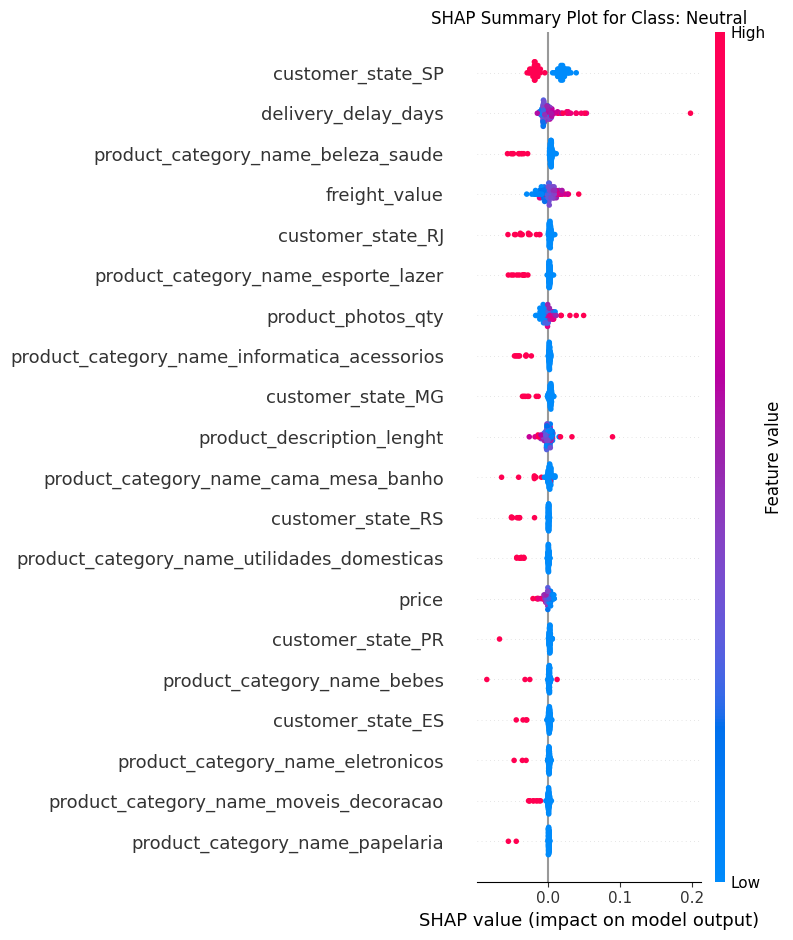


Summary plot for class: Positive


/tmp/ipython-input-1329549437.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, show=False)


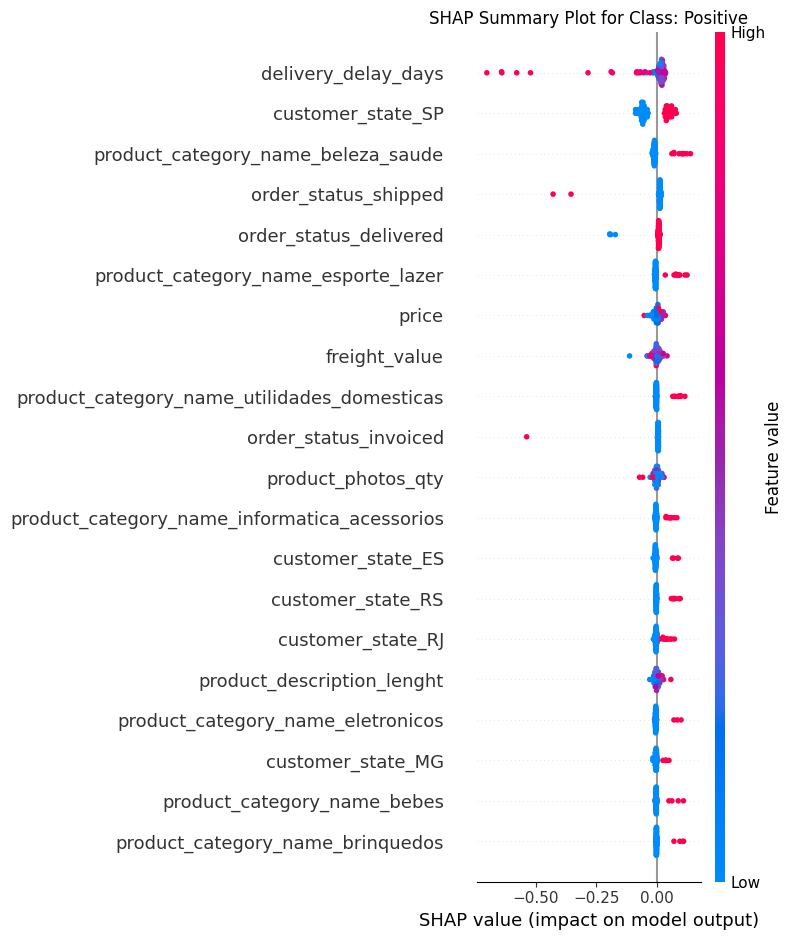


Generating combined SHAP summary plot (mean absolute SHAP value across classes)...


/tmp/ipython-input-1329549437.py:15: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)


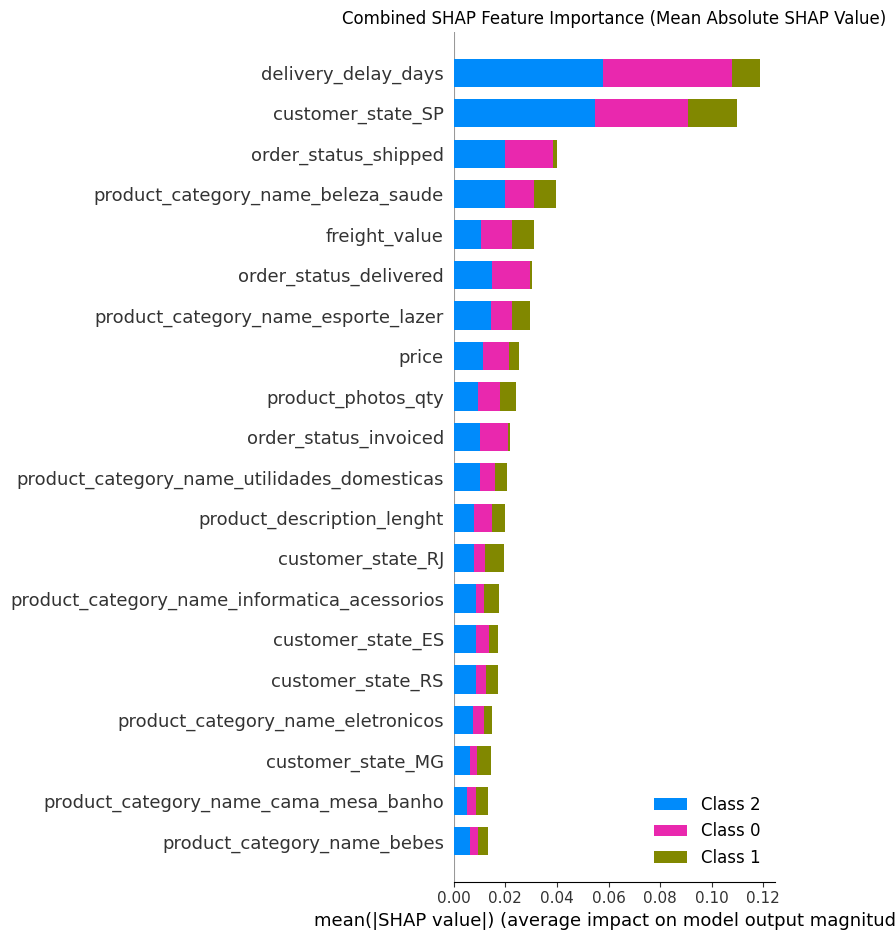

In [227]:
feature_names = X.columns.tolist()
print(feature_names)

# Create a SHAP summary plot for each class
print("Generating SHAP summary plots for each sentiment class...")
for i, name in enumerate(target_names):
    print(f"\nSummary plot for class: {name}")
    shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary Plot for Class: {name}")
    plt.tight_layout()
    plt.show()

# Optionally, a combined summary plot (mean absolute SHAP value)
print("\nGenerating combined SHAP summary plot (mean absolute SHAP value across classes)...")
shap.summary_plot(shap_values, X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)
plt.title("Combined SHAP Feature Importance (Mean Absolute SHAP Value)")
plt.tight_layout()
plt.show()

# Task
## Visualize Local Feature Importance (SHAP Force Plot)

### Subtask:
Select a specific instance from `X_test_subset_shap` (e.g., the first one) and generate a SHAP force plot for it, specifically for the 'Positive' sentiment class. This plot will provide a local explanation, detailing how each feature contributes to the model's prediction for that individual instance.

### Reasoning:
To visualize the local feature importance for a specific prediction, I will select the first instance from `X_test_subset_shap` and generate a SHAP force plot. This plot will show how each feature of that particular instance contributes to the model's output for the 'Positive' sentiment class, providing an in-depth understanding of that single prediction.

## Visualize Global Feature Importance (SHAP Summary Plots)

### Subtask:
Generate a global SHAP summary bar plot and a beeswarm plot using the calculated SHAP values for `X_test_subset_shap`. These plots will visualize the overall feature importance, showing features on the y-axis and SHAP values on the x-axis, for each of the sentiment groups (classes).


**Reasoning**:
To visualize the global feature importance for each sentiment class, I will iterate through the `shap_values` for each class and generate both SHAP summary bar plots and beeswarm plots, applying appropriate titles.



Generating SHAP summary bar plots for each sentiment class...

Summary bar plot for class: Negative


/tmp/ipython-input-971863233.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)


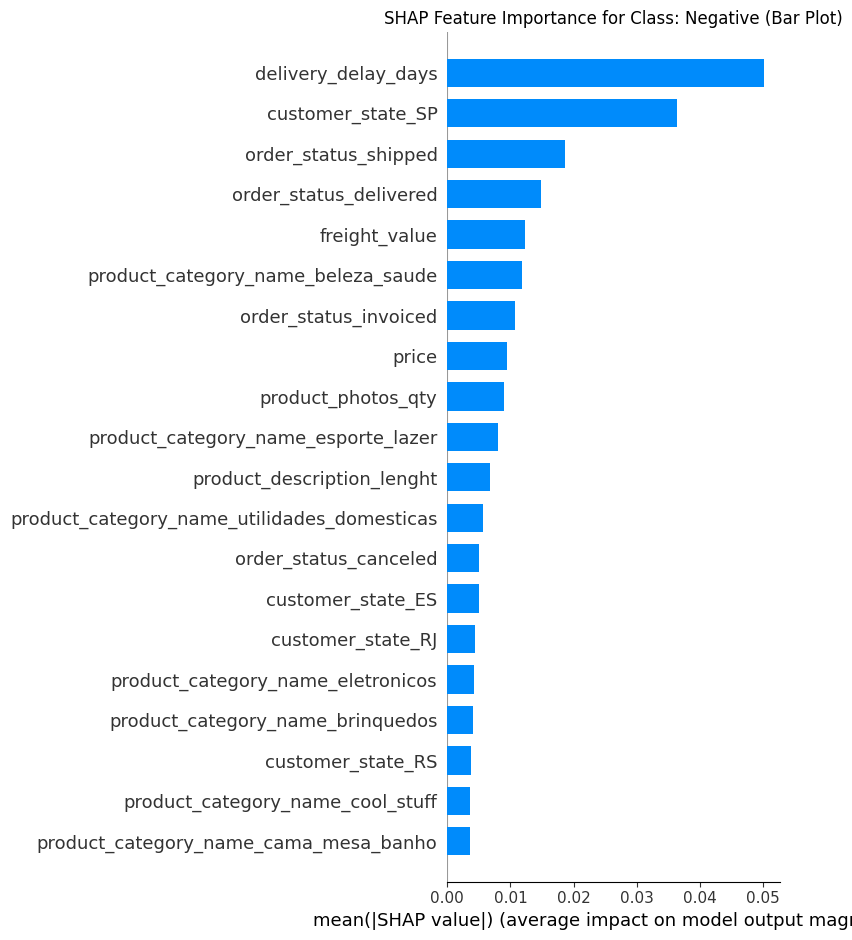


Summary bar plot for class: Neutral


/tmp/ipython-input-971863233.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)


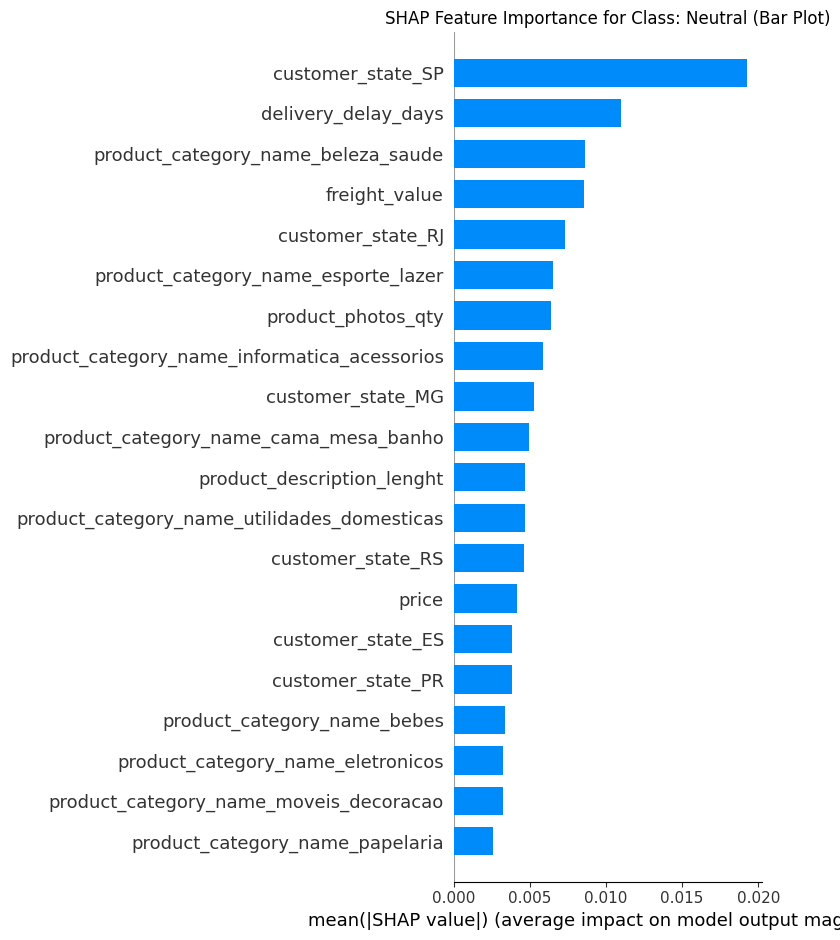


Summary bar plot for class: Positive


/tmp/ipython-input-971863233.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)


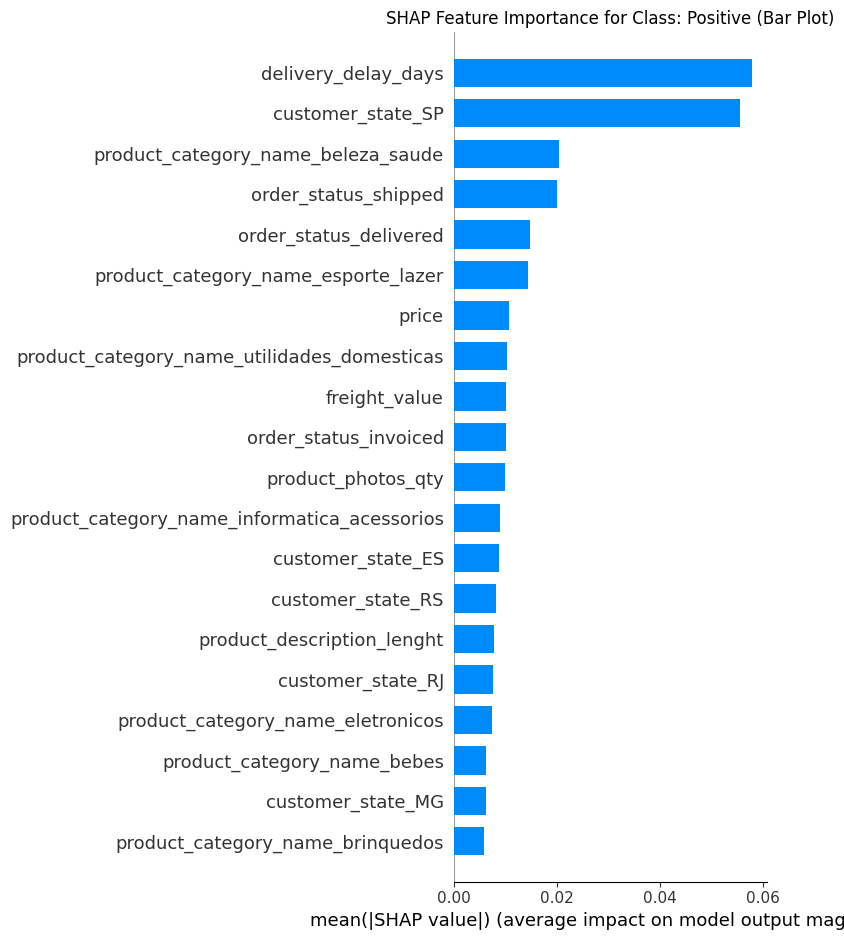


Generating SHAP beeswarm plots for each sentiment class...

Beeswarm plot for class: Negative


/tmp/ipython-input-971863233.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="dot", show=False)


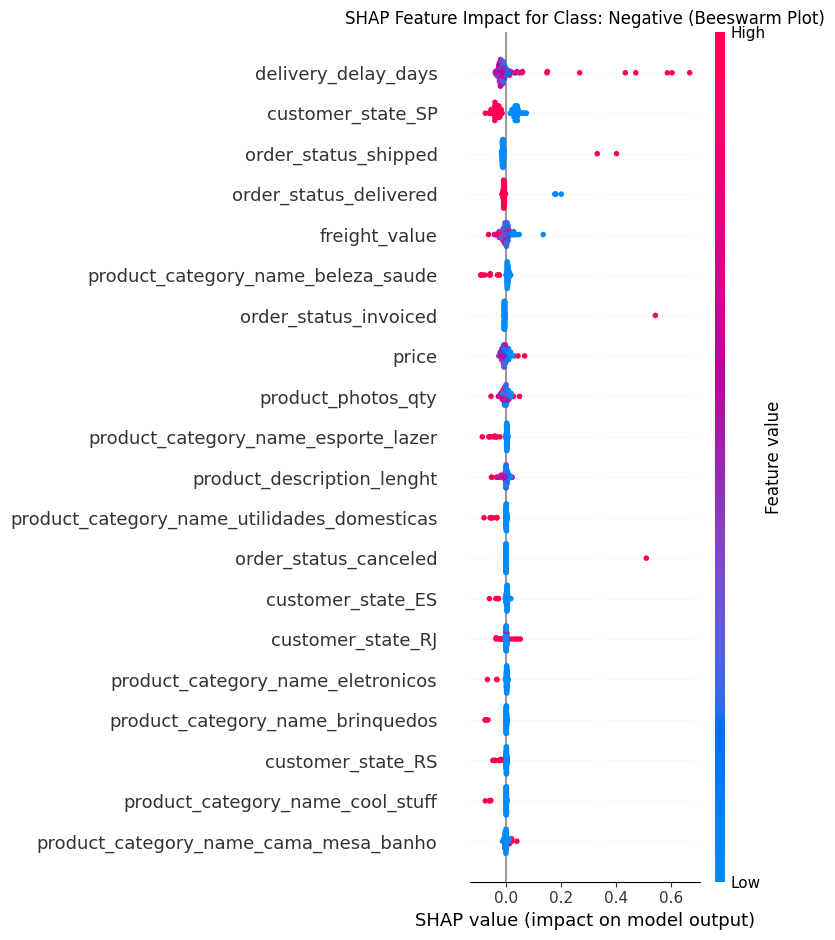


Beeswarm plot for class: Neutral


/tmp/ipython-input-971863233.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="dot", show=False)


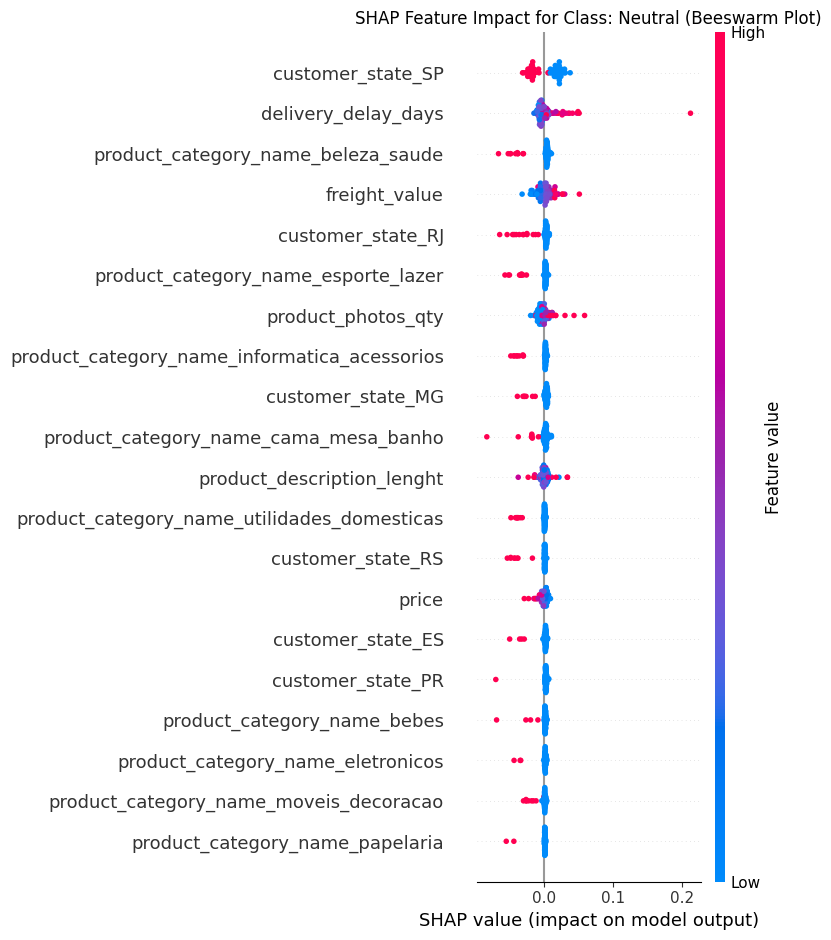


Beeswarm plot for class: Positive


/tmp/ipython-input-971863233.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="dot", show=False)


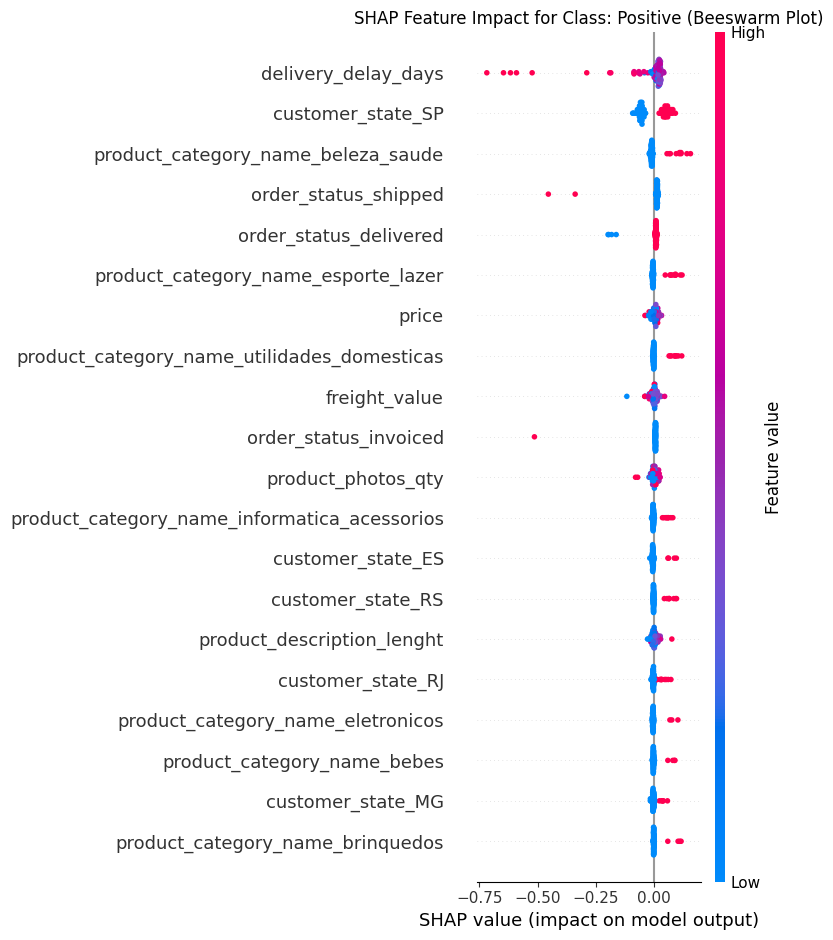

In [161]:
print("Generating SHAP summary bar plots for each sentiment class...")
for i, name in enumerate(target_names):
    print(f"\nSummary bar plot for class: {name}")
    shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance for Class: {name} (Bar Plot)")
    plt.tight_layout()
    plt.show()

print("\nGenerating SHAP beeswarm plots for each sentiment class...")
for i, name in enumerate(target_names):
    print(f"\nBeeswarm plot for class: {name}")
    shap.summary_plot(shap_values[:, :, i], X_test_subset_shap, feature_names=feature_names, plot_type="dot", show=False)
    plt.title(f"SHAP Feature Impact for Class: {name} (Beeswarm Plot)")
    plt.tight_layout()
    plt.show()

In [164]:
# shap.initjs()

# # Get shap.Explanation object for the test subset
# # This object contains base_values, shap_values, and feature data for each instance
# shap_explanation_obj = explainer(X_test_subset_shap)

# # Choose which instance you want to explain (e.g., first test row)
# instance_index = 0

# print(f"Explaining prediction for test instance {instance_index} from X_test_subset_shap:")

# # Predict probabilities for the selected instance
# predicted_probs = model.predict(X_test_subset_shap[instance_index:instance_index+1], verbose=0)[0]

# # Map predicted probabilities to sentiment group names
# predicted_sentiment = target_names[np.argmax(predicted_probs)]

# print(f"Predicted probabilities: {predicted_probs}")
# print(f"Predicted sentiment group: {predicted_sentiment}")

# # Generate a local force plot for this instance using the Explanation object
# # This plot will show the contribution of features to the prediction for all classes.
# # force plot
# shap.plots.force(
#     shap_values.values[i, :, pred_class],
#     features=X_test_subset_shap[i],
#     feature_names=feature_names
# )


In [167]:
import shap
shap.initjs()

# build NEW explainer in the new style
explainer = shap.Explainer(model, X_train_sampled_shap)

# get Explanation object
shap_values = explainer(X_test_subset_shap)

# pick instance to inspect
i = 2

# predicted class
probs = model.predict(X_test_subset_shap[i:i+1], verbose=0)[0]
pred_class = np.argmax(probs)

print("prediction probs:", probs)
print("predicted class:", target_names[pred_class])

# correct force plot call (new style)
shap.plots.force(
    shap_values.base_values[i][pred_class],
    shap_values.values[i, :, pred_class],
    X_test_subset_shap[i],
    feature_names=feature_names
)


prediction probs: [0.05801858 0.06656608 0.8754153 ]
predicted class: Positive


In [168]:
# import shap

# shap.initjs()

# # build new-style explainer (not DeepExplainer manually)
# # Use X_train_sampled_shap directly, as it's already a float NumPy array
# explainer = shap.Explainer(model, X_train_sampled_shap)

# # compute explanation object
# shap_values = explainer(X_test_subset_shap)

# # choose instance
# i = 2

# print(f"Explaining prediction for test instance {i}:")
# probs = model.predict(X_test_subset_shap[i:i+1], verbose=0)[0]
# pred_class = np.argmax(probs)
# print("pred probs:", probs)
# print("pred class:", target_names[pred_class])

# # *** NEW STYLE force plot ***
# # Extract the base value and SHAP values for the predicted class
# base_value_for_plot = shap_values.base_values[i][pred_class]
# shap_values_for_plot = shap_values.values[i][:, pred_class]

# shap.plots.force(shap_values.base_values[i][pred_class], shap_values.values[i,:,pred_class], X_test_subset_shap[i], feature_names=feature_names)


In [192]:
def predict_sentiment(new_row: pd.DataFrame):
    """
    new_row: dataframe with SAME raw columns as mergeddf
             (price, freight_value, product_category_name, customer_state, delivery_delay …)
    returns string sentiment label and its probabilities
    """

    # 1) build a dataframe with same selected_features order used in training
    row = new_row[selected_features].copy()

    # 2) convert delivery_delay to days
    row['delivery_delay_days'] = row['delivery_delay'].dt.days
    row.drop(columns=['delivery_delay'], inplace=True)

    # 3) impute median
    row['delivery_delay_days'] = row['delivery_delay_days'].fillna(median_delivery_delay)

    # 4) scale numeric features
    row_num = scaler.transform(row[numerical_cols])

    # 5) one-hot encode categoricals to same columns
    row_cat = pd.get_dummies(row[categorical_cols], drop_first=True)

    # align columns to X
    row_df = pd.DataFrame(row_num, columns=numerical_cols)
    row_df = pd.concat([row_df, row_cat], axis=1)
    row_df = row_df.reindex(columns=X.columns, fill_value=0)

    # 6) predict
    probs = model.predict(row_df, verbose=0)[0]

    idx = np.argmax(probs)
    predicted_label = target_names[idx]

    return predicted_label, {name: prob for name, prob in zip(target_names, probs)}


In [207]:
dummy_new_review = {
    "product_description_lenght": 150,
    "product_photos_qty": 10,  # High quantity of photos for positive impact
    "product_category_name": "beleza_saude", # Category with generally higher review scores
    "customer_state": "SP",
    "order_status": "delivered",
    "delivery_delay": pd.to_datetime("2023-05-06") - pd.to_datetime("2023-05-16"), # -10 days (very early delivery)
    "price": 50.00, # Lower price for better sentiment
    "freight_value": 10.00 # Lower freight value for better sentiment
}

#print all the column names in mergeddf
print(mergeddf.columns.tolist())

['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_delay', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_id', 'review_score', 'review_creation_date', 'review_answer_timestamp', 'is_negative', 'delay_bin', 'sentiment_group']


In [225]:
dummy_new_review_full = {
    'order_id': 'dummy_order_id_123',
    'order_item_id': 1,
    'product_id': 'dummy_product_id_123',
    'seller_id': 'dummy_seller_id_123',
    'shipping_limit_date': pd.to_datetime('2023-05-15 10:00:00'),
    'price': 89.90,
    'freight_value': 15.50,
    'product_category_name': 'beleza_saude',
    'product_name_lenght': 50.0,
    'product_description_lenght': 150.0,
    'product_photos_qty': 20.0,
    'product_weight_g': 500.0,
    'product_length_cm': 30.0,
    'product_height_cm': 10.0,
    'product_width_cm': 20.0,
    'customer_id': 'dummy_customer_id_123',
    'order_status': 'delivered',
    'order_purchase_timestamp': pd.to_datetime('2023-05-01 10:00:00'),
    'order_approved_at': pd.to_datetime('2023-05-01 10:30:00'),
    'order_delivered_carrier_date': pd.to_datetime('2023-05-05 10:00:00'),
    'order_delivered_customer_date': pd.to_datetime('2023-05-06 10:00:00'), # Early delivery
    'order_estimated_delivery_date': pd.to_datetime('2023-05-16 10:00:00'),
    'delivery_delay': pd.to_datetime('2023-05-06 10:00:00') - pd.to_datetime('2023-05-16 10:00:00'), # -10 days
    'customer_unique_id': 'dummy_unique_id_123',
    'customer_zip_code_prefix': 12345,
    'customer_city': 'sao paulo',
    'customer_state': 'SP',
    'review_id': 'dummy_review_id_123',
    'review_creation_date': pd.to_datetime('2023-05-07 10:00:00'),
    'review_answer_timestamp': pd.to_datetime('2023-05-07 11:00:00'),
    #'is_negative': False,
}

# Note: The predict_sentiment function only uses a subset of these features.
# When using predict_sentiment, you would typically pass only the relevant columns.
# However, if you pass a DataFrame with all columns, the function will extract the ones it needs.


In [226]:
example = mergeddf.iloc[[2]]   # row 0 as example
# Convert the dummy_new_review dictionary into a pandas DataFrame with a single row
new_review_df = pd.DataFrame([dummy_new_review_full])

# Now, pass the DataFrame to the predict_sentiment function
predicted_sentiment, probabilities = predict_sentiment(new_review_df)

print(f"Predicted sentiment example: {predicted_sentiment}")
print(f"Probabilities: {probabilities}")

Predicted sentiment example: Neutral
Probabilities: {'Negative': np.float32(0.23609701), 'Neutral': np.float32(0.7008677), 'Positive': np.float32(0.06303528)}
